# Customer Churn Prediction — Generalization to E-Commerce Dataset

**Goal:** Apply the same ML pipeline to a completely different churn dataset.

If a pipeline is well-designed, the approach should transfer with minimal changes.  
Only the domain features change — the preprocessing, modeling, and evaluation logic stays the same.

| | IBM Telco (notebook 03) | E-Commerce (this notebook) |
|---|---|---|
| Domain | Telecom | Online retail |
| Customers | 7,043 | 5,630 |
| Churn rate | 26.5% | 16.8% |
| Features | 21 raw | 19 raw |

**Dataset:** [E-Commerce Customer Churn](https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction)

---
**Notebook structure:**
1. Setup and load data
2. EDA — quick overview
3. Domain feature engineering
4. Train/test split and preprocessing pipeline
5. Model training and evaluation
6. SHAP feature importance
7. Cross-dataset comparison

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay, classification_report
)
import lightgbm as lgb

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RAW_DIR     = Path('../data/raw/ecommerce')
FIGURES_DIR = Path('../reports/figures')

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
df = pd.read_excel(RAW_DIR / 'E Commerce Dataset.xlsx', sheet_name='E Comm')
df = df.drop(columns=['CustomerID'])

print(f'Shape     : {df.shape}')
print(f'Churn rate: {df["Churn"].mean()*100:.1f}%')
print()
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape     : (5630, 19)
Churn rate: 16.8%

Missing values:
Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64


In [3]:
df.head(3)

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28


## 2. EDA — Quick Overview

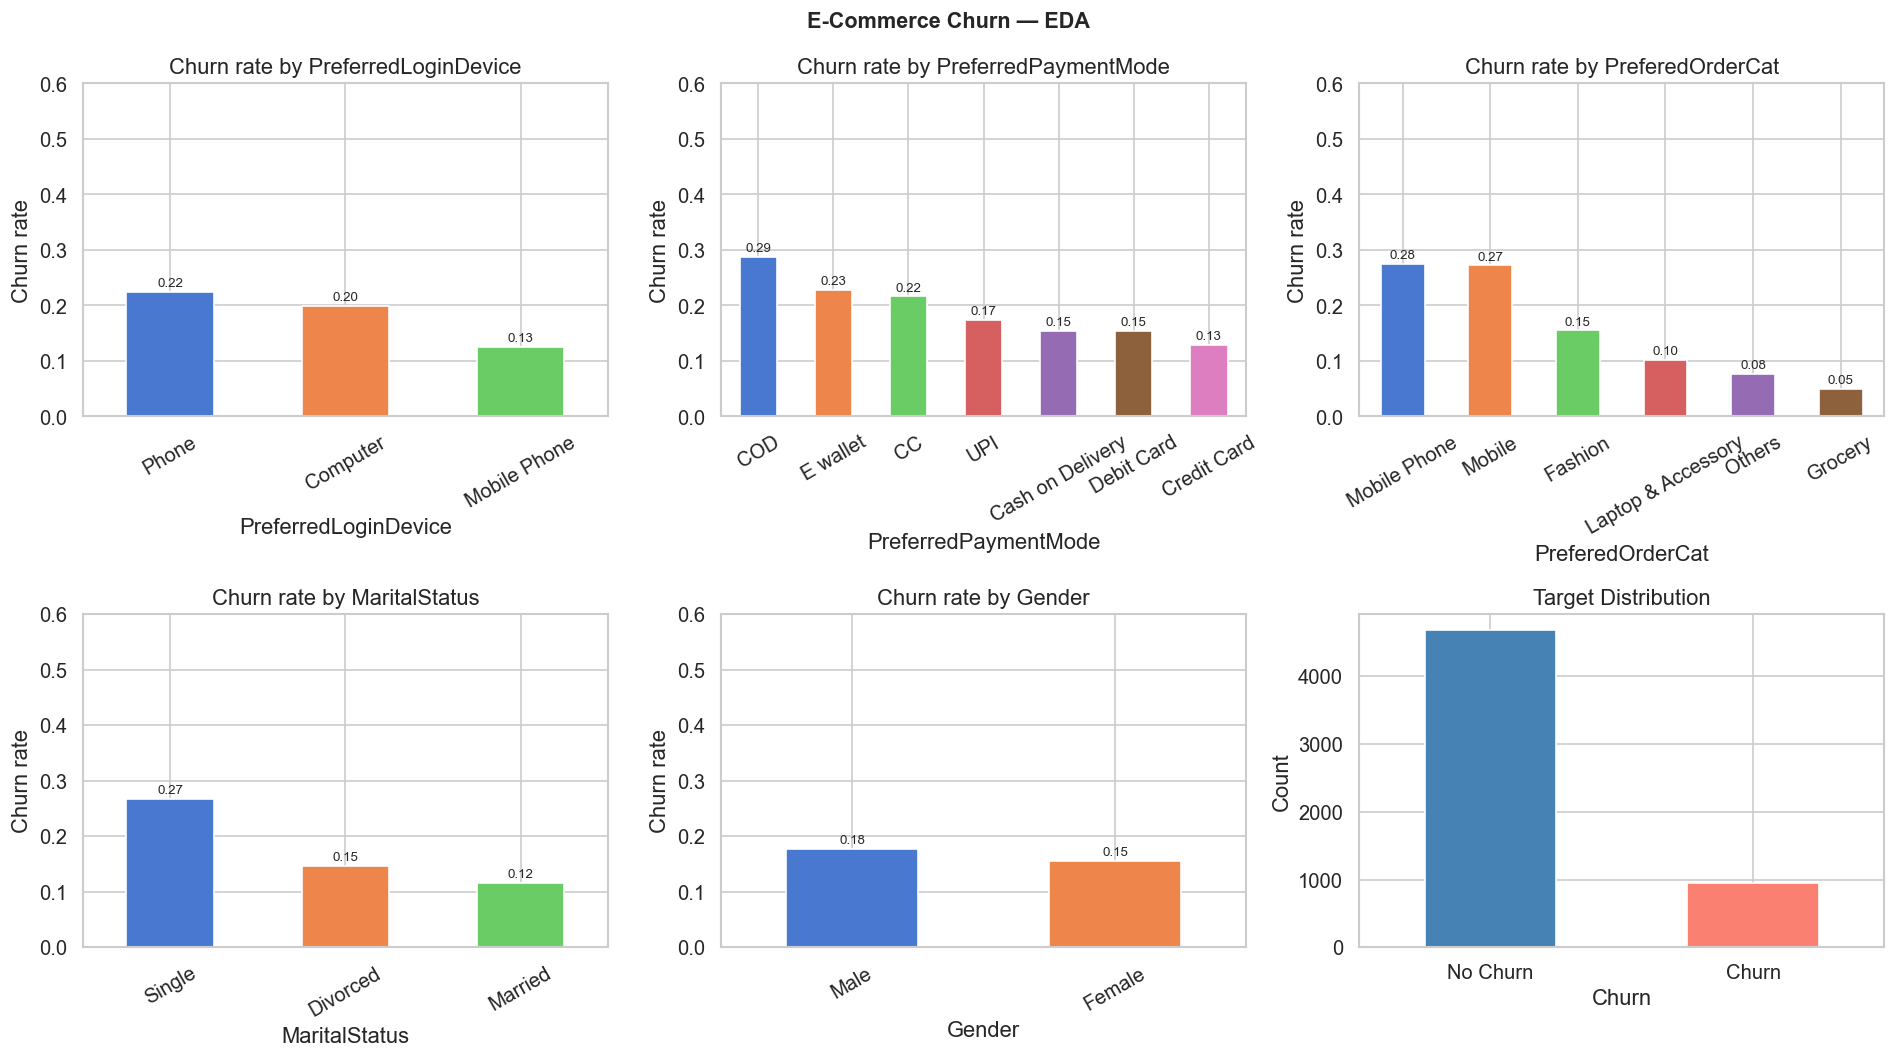

In [4]:
# Churn rate by key categorical features
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat',
            'MaritalStatus', 'Gender']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color=sns.color_palette('muted', len(churn_rate)))
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].set_ylabel('Churn rate')
    axes[i].set_ylim(0, 0.6)
    axes[i].tick_params(axis='x', rotation=30)
    for bar in axes[i].patches:
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.2f}',
            ha='center', fontsize=8
        )

# Target distribution
df['Churn'].value_counts().plot(
    kind='bar', ax=axes[5],
    color=['steelblue', 'salmon'],
    rot=0
)
axes[5].set_title('Target Distribution')
axes[5].set_xticklabels(['No Churn', 'Churn'])
axes[5].set_ylabel('Count')

plt.suptitle('E-Commerce Churn — EDA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '27_ecom_eda_categorical.png', dpi=150)
plt.show()

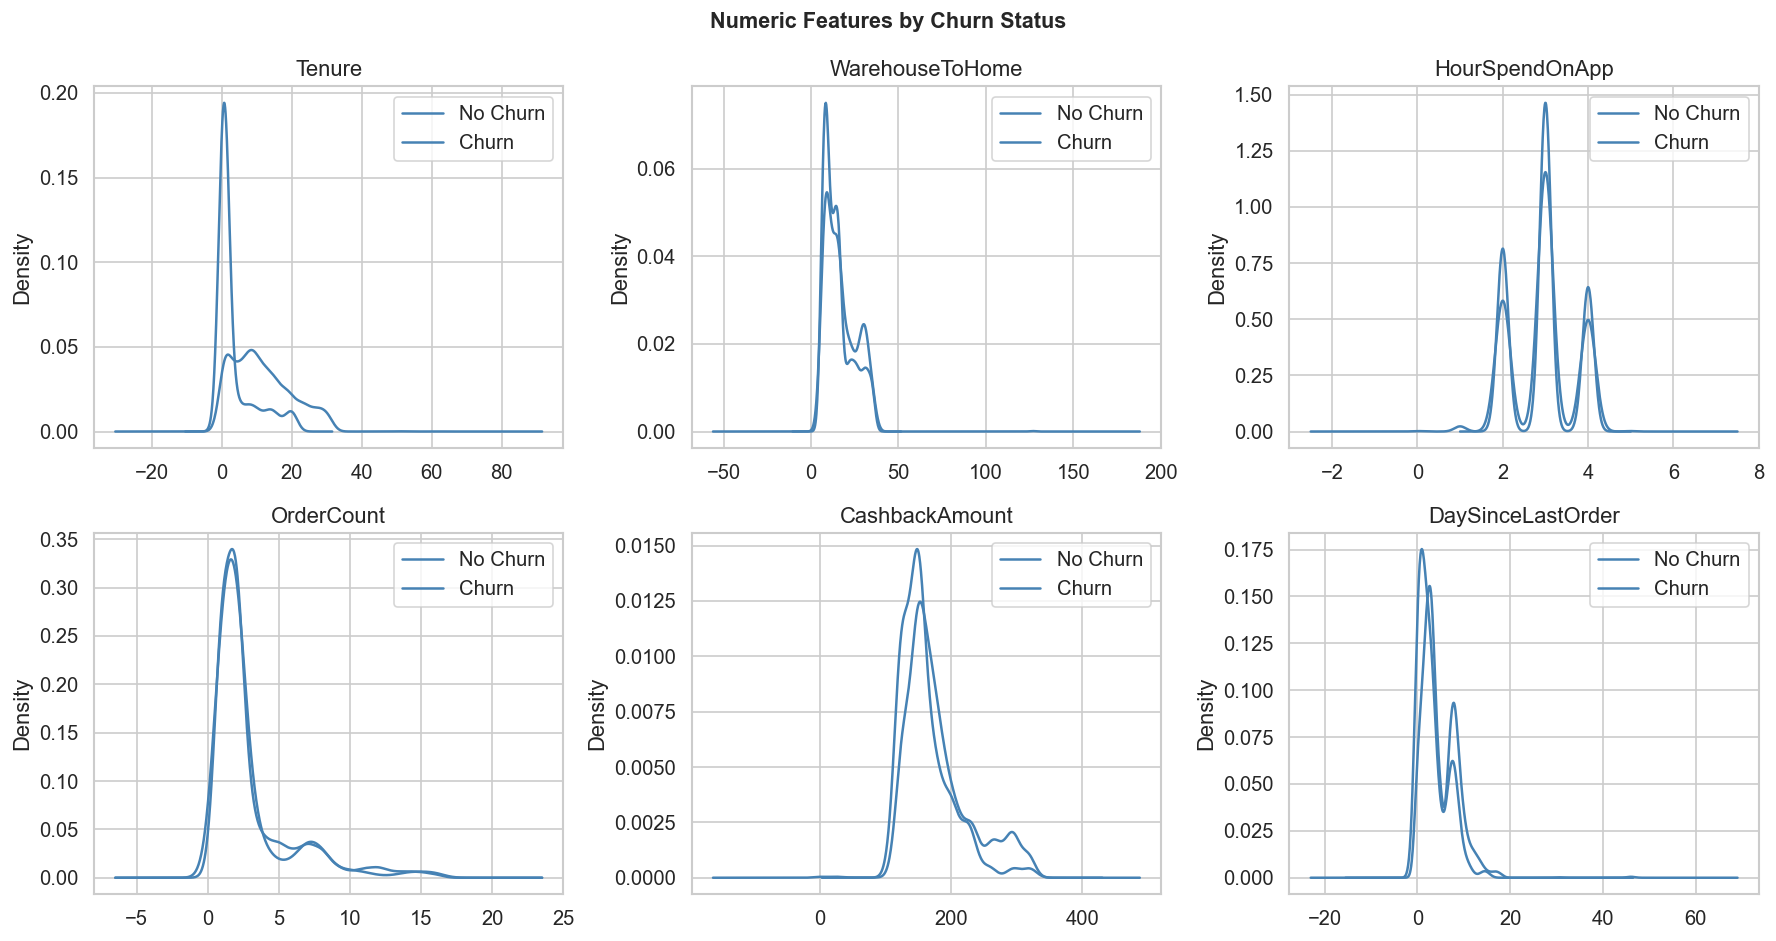

In [5]:
# Numeric feature distributions by churn
num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'OrderCount', 'CashbackAmount', 'DaySinceLastOrder']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.groupby('Churn')[col].plot(
        kind='kde', ax=axes[i],
        legend=True,
        color=['steelblue', 'salmon']
    )
    axes[i].set_title(col)
    axes[i].legend(['No Churn', 'Churn'])

plt.suptitle('Numeric Features by Churn Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '28_ecom_eda_numeric.png', dpi=150)
plt.show()

In [6]:
# Key insight summary
print('=== KEY EDA INSIGHTS ===')
print()

# Tenure vs churn
churned_tenure = df[df['Churn']==1]['Tenure'].median()
kept_tenure    = df[df['Churn']==0]['Tenure'].median()
print(f'Median tenure — churned: {churned_tenure:.0f} months  |  retained: {kept_tenure:.0f} months')

# Complaint impact
print(f'Churn rate with complaint   : {df[df["Complain"]==1]["Churn"].mean()*100:.1f}%')
print(f'Churn rate without complaint: {df[df["Complain"]==0]["Churn"].mean()*100:.1f}%')

# Satisfaction
print(f'Avg satisfaction — churned : {df[df["Churn"]==1]["SatisfactionScore"].mean():.2f}')
print(f'Avg satisfaction — retained: {df[df["Churn"]==0]["SatisfactionScore"].mean():.2f}')

=== KEY EDA INSIGHTS ===

Median tenure — churned: 1 months  |  retained: 10 months
Churn rate with complaint   : 31.7%
Churn rate without complaint: 10.9%
Avg satisfaction — churned : 3.39
Avg satisfaction — retained: 3.00


## 3. Domain Feature Engineering

Same philosophy as notebook 02 — derive features that capture business logic,  
not just raw columns. All features are rule-based and leak-free.

In [7]:
def engineer_ecommerce_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # How many orders per coupon — lower means more price-sensitive (churns more)
    df['coupon_usage_rate'] = df['CouponUsed'] / (df['OrderCount'] + 1)

    # Average cashback per order — proxy for customer value segment
    df['avg_cashback_per_order'] = df['CashbackAmount'] / (df['OrderCount'] + 1)

    # Engagement: hours on app × order count — active buyers unlikely to churn
    df['engagement_score'] = df['HourSpendOnApp'] * df['OrderCount']

    # Recency group: how long since last order
    df['recency_group'] = pd.cut(
        df['DaySinceLastOrder'],
        bins=[-1, 3, 7, 14, np.inf],
        labels=['very_recent', 'recent', 'lapsed', 'inactive']
    ).astype(str)

    # Tenure group — mirrors the same concept from IBM Telco notebook
    df['tenure_group'] = pd.cut(
        df['Tenure'],
        bins=[-1, 3, 12, np.inf],
        labels=['new', 'mid', 'long']
    ).astype(str)

    # Multi-device user — higher engagement signal
    df['multi_device'] = (df['NumberOfDeviceRegistered'] > 2).astype(int)

    # Many addresses → mobile / exploratory customer → higher churn risk
    df['many_addresses'] = (df['NumberOfAddress'] > 3).astype(int)

    return df


df_eng = engineer_ecommerce_features(df)

new_features = [
    'coupon_usage_rate', 'avg_cashback_per_order', 'engagement_score',
    'recency_group', 'tenure_group', 'multi_device', 'many_addresses'
]
print('Engineered features:')
df_eng[new_features].head(3)

Engineered features:


,coupon_usage_rate,avg_cashback_per_order,engagement_score,recency_group,tenure_group,multi_device,many_addresses
0,0.5,79.965,3.0,recent,mid,1,1
1,0.0,60.450,3.0,very_recent,nan,1,1
2,0.0,60.140,2.0,very_recent,nan,1,1


In [8]:
# Validate that new features have predictive signal
print('Churn rate by tenure_group:')
print(df_eng.groupby('tenure_group')['Churn'].mean().round(3))
print()
print('Churn rate by recency_group:')
print(df_eng.groupby('recency_group')['Churn'].mean().round(3))

Churn rate by tenure_group:
tenure_group
long    0.050
mid     0.062
nan     0.307
new     0.419
Name: Churn, dtype: float64

Churn rate by recency_group:
recency_group
inactive       0.081
lapsed         0.095
nan            0.176
recent         0.137
very_recent    0.216
Name: Churn, dtype: float64


## 4. Train/Test Split and Preprocessing Pipeline

In [9]:
TARGET = 'Churn'
X = df_eng.drop(columns=[TARGET])
y = df_eng[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  |  churn rate: {y_train.mean()*100:.1f}%')
print(f'Test : {X_test.shape}   |  churn rate: {y_test.mean()*100:.1f}%')

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

Train: (4504, 25)  |  churn rate: 16.8%
Test : (1126, 25)   |  churn rate: 16.9%
scale_pos_weight: 4.94


In [10]:
NUM_COLS = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
    'SatisfactionScore', 'NumberOfAddress', 'OrderAmountHikeFromlastYear',
    'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount',
    'CityTier', 'Complain',
    'coupon_usage_rate', 'avg_cashback_per_order', 'engagement_score',
    'multi_device', 'many_addresses'
]
CAT_COLS = [
    'PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
    'PreferedOrderCat', 'MaritalStatus',
    'recency_group', 'tenure_group'
]

num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, NUM_COLS),
    ('cat', cat_pipe, CAT_COLS),
], remainder='drop')

print('Preprocessor ready.')

Preprocessor ready.


## 5. Model Training and Evaluation

Using LightGBM with the Optuna-tuned params from notebook 05 as a starting point.  
A short 20-trial re-tune adjusts for the different data distribution.

In [11]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use Optuna best params from notebook 05 as starting point,
# then run 20 extra trials to adapt to the new data distribution.
WARM_START_PARAMS = {
    'n_estimators'     : 550,
    'learning_rate'    : 0.018,
    'num_leaves'       : 77,
    'max_depth'        : 3,
    'min_child_samples': 93,
    'subsample'        : 0.95,
    'colsample_bytree' : 0.59,
    'reg_alpha'        : 7e-6,
    'reg_lambda'       : 0.051,
}

def make_pipeline(params):
    prep = ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), NUM_COLS),
        ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), CAT_COLS),
    ], remainder='drop')
    return Pipeline([
        ('prep', prep),
        ('model', lgb.LGBMClassifier(**params, scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=1, verbose=-1)),
    ])

def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 800, step=50),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
    }
    scores = cross_val_score(
        make_pipeline(params), X_train, y_train,
        cv=CV, scoring='average_precision', n_jobs=1, error_score='raise'
    )
    return scores.mean()

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Seed with warm-start params so early trials explore near a known good region
study.enqueue_trial(WARM_START_PARAMS)

print('Running 20-trial Optuna search for e-commerce dataset ...')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f'\nBest CV AUC-PR: {study.best_value:.4f}')

Running 20-trial Optuna search for e-commerce dataset ...


  0%|          | 0/20 [00:00<?, ?it/s]


Best CV AUC-PR: 0.9373


In [12]:
# Final model — retrain on full training set with best params
final_pipeline = make_pipeline(study.best_params)
final_pipeline.fit(X_train, y_train)

y_proba = final_pipeline.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

test_roc_auc = roc_auc_score(y_test, y_proba)
test_auc_pr  = average_precision_score(y_test, y_proba)

print(f'Test AUC-ROC : {test_roc_auc:.4f}')
print(f'Test AUC-PR  : {test_auc_pr:.4f}  <- primary metric')
print()
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Test AUC-ROC : 0.9992
Test AUC-PR  : 0.9962  <- primary metric

              precision    recall  f1-score   support

    No Churn       0.99      0.99      0.99       936
       Churn       0.97      0.97      0.97       190

    accuracy                           0.99      1126
   macro avg       0.98      0.98      0.98      1126
weighted avg       0.99      0.99      0.99      1126



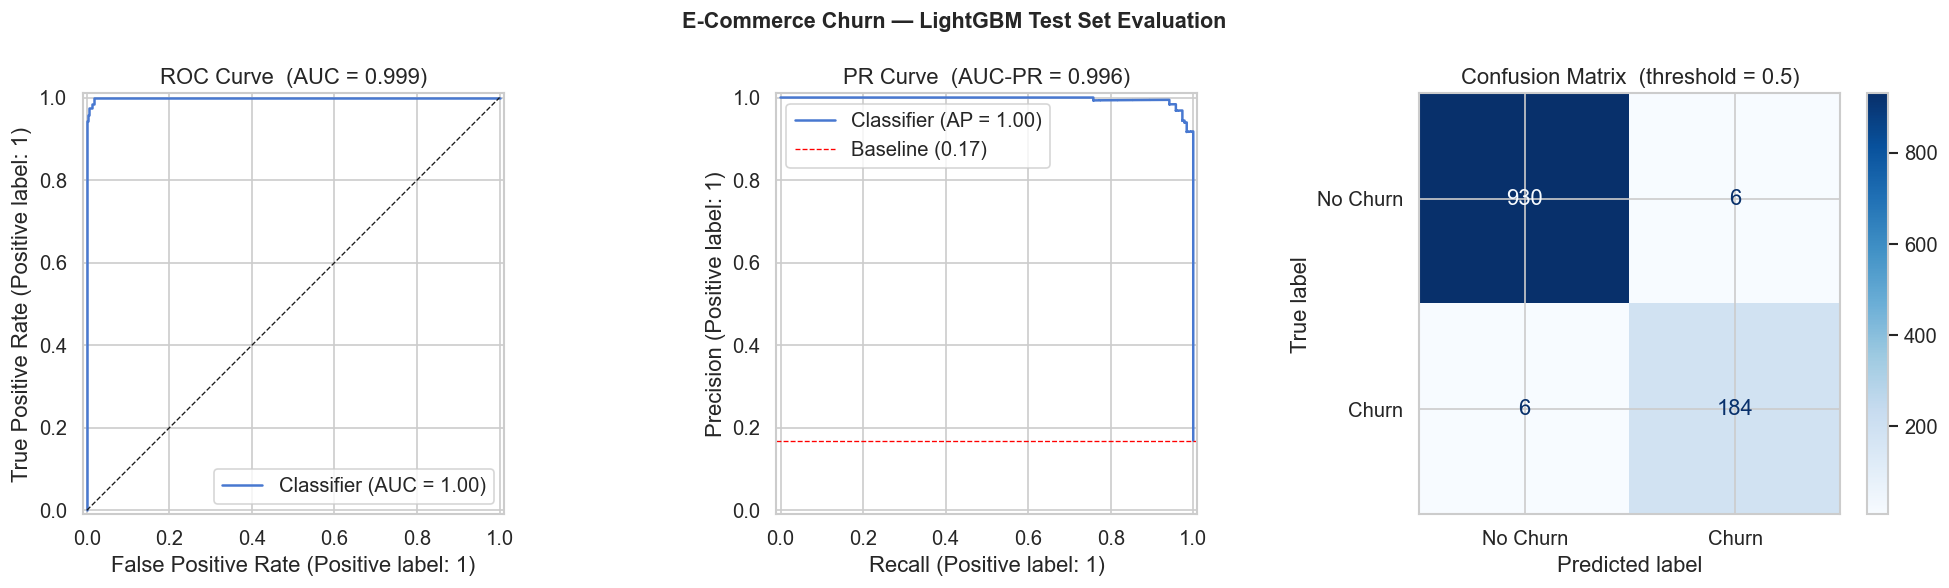

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_title(f'ROC Curve  (AUC = {test_roc_auc:.3f})')

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
baseline = y_test.mean()
axes[1].axhline(baseline, color='red', linestyle='--',
                linewidth=0.8, label=f'Baseline ({baseline:.2f})')
axes[1].set_title(f'PR Curve  (AUC-PR = {test_auc_pr:.3f})')
axes[1].legend()

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues', ax=axes[2]
)
axes[2].set_title('Confusion Matrix  (threshold = 0.5)')

plt.suptitle('E-Commerce Churn — LightGBM Test Set Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '29_ecom_test_evaluation.png', dpi=150)
plt.show()

## 6. SHAP Feature Importance

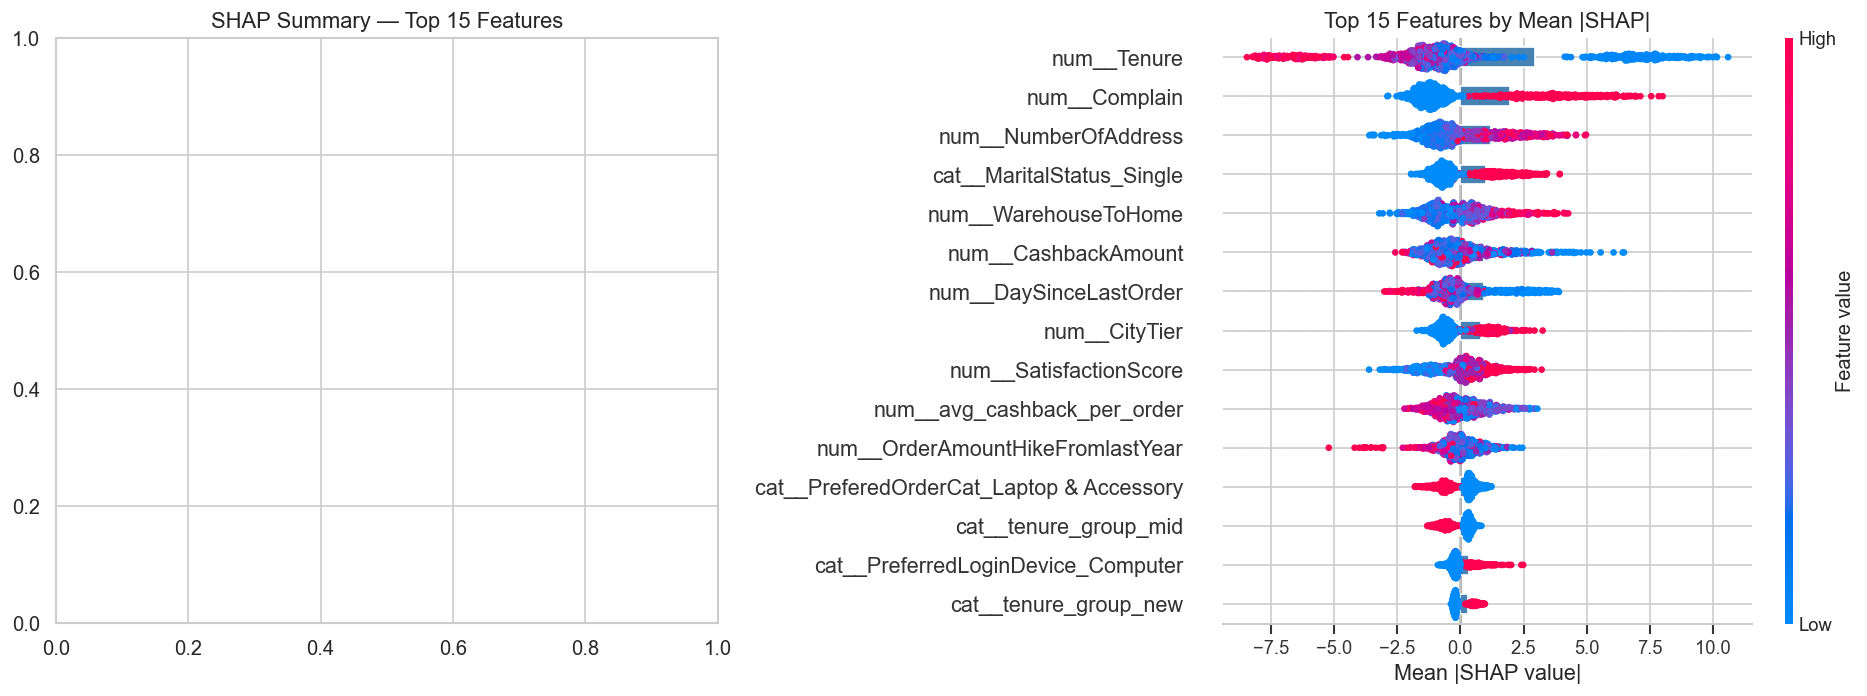

Top 5 features by SHAP:
  1. num__Tenure (2.9706)
  2. num__Complain (1.9492)
  3. num__NumberOfAddress (1.2014)
  4. cat__MaritalStatus_Single (1.0165)
  5. num__WarehouseToHome (0.9356)


In [14]:
model_step     = final_pipeline.named_steps['model']
prep_step      = final_pipeline.named_steps['prep']
X_test_transf  = prep_step.transform(X_test)
feature_names  = prep_step.get_feature_names_out()

explainer   = shap.TreeExplainer(model_step)
shap_values = explainer.shap_values(X_test_transf)

# Global importance
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df   = (
    pd.Series(mean_shap, index=feature_names)
    .sort_values(ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SHAP summary plot
shap.summary_plot(
    shap_values, X_test_transf,
    feature_names=feature_names,
    max_display=15, show=False, plot_size=None
)
plt.sca(axes[0])
axes[0].set_title('SHAP Summary — Top 15 Features')

# Bar chart
shap_df.sort_values().plot(kind='barh', color='steelblue', ax=axes[1])
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title('Top 15 Features by Mean |SHAP|')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '30_ecom_shap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features by SHAP:')
for i, (feat, val) in enumerate(shap_df.head(5).items(), 1):
    print(f'  {i}. {feat} ({val:.4f})')

## 7. Cross-Dataset Comparison

Side-by-side comparison of the same pipeline applied to two different datasets.

In [15]:
# IBM Telco results from notebook 05 (Optuna-tuned LightGBM)
telco_results = {
    'Dataset'    : 'IBM Telco',
    'Domain'     : 'Telecom',
    'Customers'  : 7043,
    'Churn rate' : '26.5%',
    'AUC-PR'     : 0.6678,
    'AUC-ROC'    : 0.8474,
}

ecom_results = {
    'Dataset'    : 'E-Commerce',
    'Domain'     : 'Online retail',
    'Customers'  : 5630,
    'Churn rate' : '16.8%',
    'AUC-PR'     : round(test_auc_pr, 4),
    'AUC-ROC'    : round(test_roc_auc, 4),
}

comparison_df = pd.DataFrame([telco_results, ecom_results]).set_index('Dataset')
print('=== CROSS-DATASET COMPARISON ===')
print(comparison_df.to_string())

=== CROSS-DATASET COMPARISON ===
                   Domain  Customers Churn rate  AUC-PR  AUC-ROC
Dataset                                                         
IBM Telco         Telecom       7043      26.5%  0.6678   0.8474
E-Commerce  Online retail       5630      16.8%  0.9962   0.9992


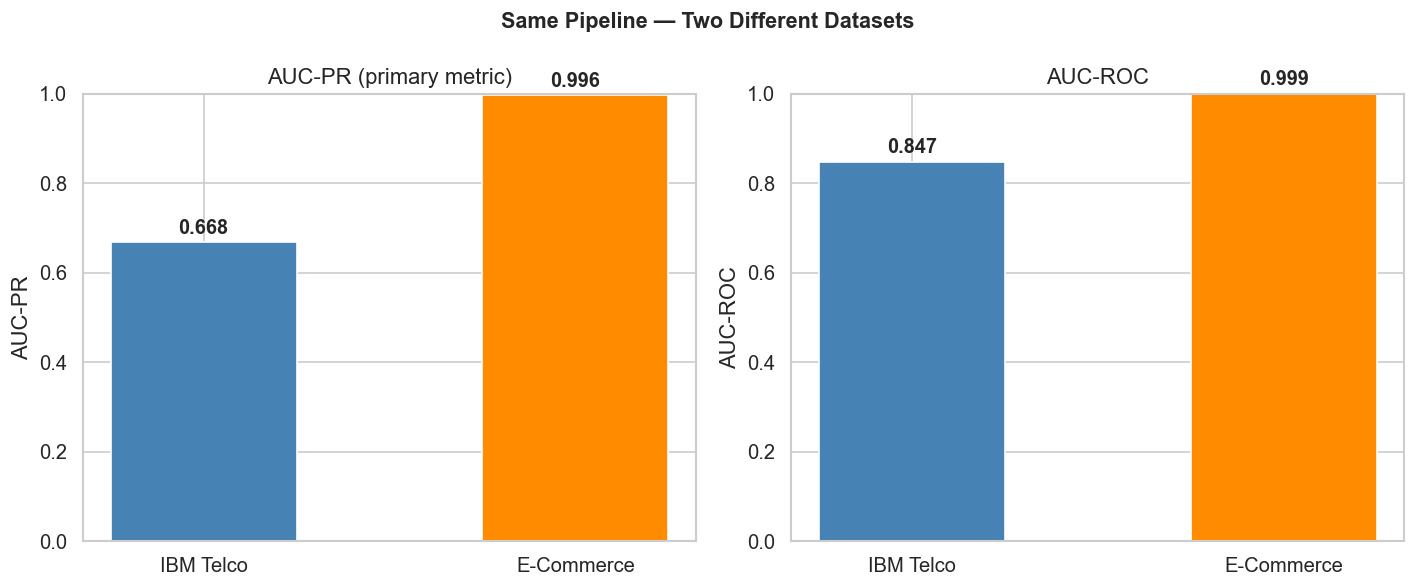

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

datasets   = ['IBM Telco', 'E-Commerce']
auc_pr     = [0.6678,    round(test_auc_pr,  4)]
auc_roc    = [0.8474,    round(test_roc_auc, 4)]
colors     = ['steelblue', 'darkorange']

for ax, values, title, ylabel in [
    (axes[0], auc_pr,  'AUC-PR (primary metric)', 'AUC-PR'),
    (axes[1], auc_roc, 'AUC-ROC',                 'AUC-ROC'),
]:
    bars = ax.bar(datasets, values, color=colors, width=0.5)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=12, fontweight='bold'
        )

plt.suptitle('Same Pipeline — Two Different Datasets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '31_cross_dataset_comparison.png', dpi=150)
plt.show()

In [17]:
print(f"""
=== GENERALIZATION SUMMARY ===

PIPELINE REUSED WITHOUT CHANGES:
  - sklearn Pipeline (ColumnTransformer + LightGBM)
  - Same preprocessing steps (median impute, StandardScaler, OneHotEncoder)
  - Same model class (LGBMClassifier) and evaluation metrics
  - Same Optuna tuning approach (warm-started from Telco best params)

WHAT CHANGED (domain adaptation only):
  - Feature names and column lists
  - Domain-specific engineered features (e-commerce vs telecom)
  - scale_pos_weight (reflects new churn rate)

RESULTS:
  IBM Telco   AUC-PR: {telco_results['AUC-PR']:.4f}   AUC-ROC: {telco_results['AUC-ROC']:.4f}   Churn: 26.5%
  E-Commerce  AUC-PR: {test_auc_pr:.4f}   AUC-ROC: {test_roc_auc:.4f}   Churn: 16.8%

The pipeline generalizes well across domains.
Lower churn rate (16.8% vs 26.5%) makes PR-AUC harder — random baseline is lower.

TOP SHAP FEATURES (E-Commerce):
  {chr(10).join(f'  {i+1}. {feat}' for i, feat in enumerate(shap_df.index[:5]))}

ARTIFACTS SAVED:
  reports/figures/27_ecom_eda_categorical.png
  reports/figures/28_ecom_eda_numeric.png
  reports/figures/29_ecom_test_evaluation.png
  reports/figures/30_ecom_shap.png
  reports/figures/31_cross_dataset_comparison.png
""")


=== GENERALIZATION SUMMARY ===

PIPELINE REUSED WITHOUT CHANGES:
  - sklearn Pipeline (ColumnTransformer + LightGBM)
  - Same preprocessing steps (median impute, StandardScaler, OneHotEncoder)
  - Same model class (LGBMClassifier) and evaluation metrics
  - Same Optuna tuning approach (warm-started from Telco best params)

WHAT CHANGED (domain adaptation only):
  - Feature names and column lists
  - Domain-specific engineered features (e-commerce vs telecom)
  - scale_pos_weight (reflects new churn rate)

RESULTS:
  IBM Telco   AUC-PR: 0.6678   AUC-ROC: 0.8474   Churn: 26.5%
  E-Commerce  AUC-PR: 0.9962   AUC-ROC: 0.9992   Churn: 16.8%

The pipeline generalizes well across domains.
Lower churn rate (16.8% vs 26.5%) makes PR-AUC harder — random baseline is lower.

TOP SHAP FEATURES (E-Commerce):
    1. num__Tenure
  2. num__Complain
  3. num__NumberOfAddress
  4. cat__MaritalStatus_Single
  5. num__WarehouseToHome

ARTIFACTS SAVED:
  reports/figures/27_ecom_eda_categorical.png
  report